In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set(style="darkgrid")

In [4]:
df = pd.read_csv('Pokemon.csv')

In [5]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [6]:
len(df)

800

In [7]:
df.dtypes

#              int64
Name          object
Type 1        object
Type 2        object
Total          int64
HP             int64
Attack         int64
Defense        int64
Sp. Atk        int64
Sp. Def        int64
Speed          int64
Generation     int64
Legendary       bool
dtype: object

In [8]:
df.columns = ['#', 'Nom', 'Tipus1', 'Tipus2', 'Total', 'HP', 'Attack', 'Defense', 'SPA', 'SPD', 'Speed', 'Gen', 'Legendary']

In [9]:
df.head()

,#,Nom,Tipus1,Tipus2,Total,HP,Attack,Defense,SPA,SPD,Speed,Gen,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [10]:
pokemon_tipo = df.Tipus1.str.contains('Fire')

In [11]:
df.loc[pokemon_tipo].head()

,#,Nom,Tipus1,Tipus2,Total,HP,Attack,Defense,SPA,SPD,Speed,Gen,Legendary
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False


In [12]:
set(df.Nom[pokemon_tipo])

{'Arcanine',
 'Blaziken',
 'BlazikenMega Blaziken',
 'Braixen',
 'Camerupt',
 'CameruptMega Camerupt',
 'Charizard',
 'CharizardMega Charizard X',
 'CharizardMega Charizard Y',
 'Charmander',
 'Charmeleon',
 'Chimchar',
 'Combusken',
 'Cyndaquil',
 'DarmanitanStandard Mode',
 'DarmanitanZen Mode',
 'Darumaka',
 'Delphox',
 'Emboar',
 'Entei',
 'Fennekin',
 'Flareon',
 'Fletchinder',
 'Growlithe',
 'Heatmor',
 'Heatran',
 'Ho-oh',
 'Infernape',
 'Litleo',
 'Magby',
 'Magcargo',
 'Magmar',
 'Magmortar',
 'Moltres',
 'Monferno',
 'Ninetales',
 'Numel',
 'Pansear',
 'Pignite',
 'Ponyta',
 'Pyroar',
 'Quilava',
 'Rapidash',
 'Simisear',
 'Slugma',
 'Talonflame',
 'Tepig',
 'Torchic',
 'Torkoal',
 'Typhlosion',
 'Volcanion',
 'Vulpix'}

In [13]:
len(df.Nom[pokemon_tipo])

52

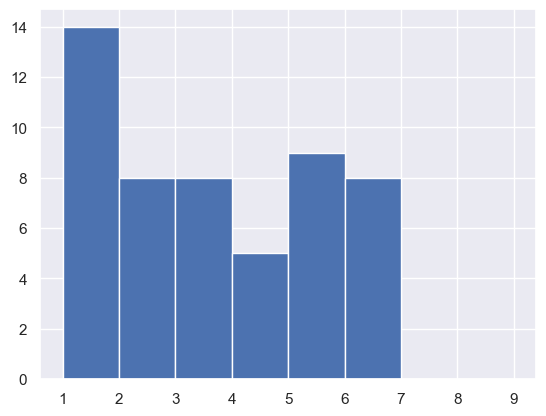

In [14]:
bin_sizes, _, _ = plt.hist(df.Gen[pokemon_tipo], bins=range(1, 10))

In [15]:
#Emmagatzemar registres amb els atributs especificats agrupats per generació
group_by_gen = df.loc[:, ['Nom', 'Tipus1', 'Total', 'Gen']].groupby('Gen')
#Realitzar la mitjana
avgs = group_by_gen.mean()
#Assigna l'índex de la sèrie avgs a la variable x.
x = avgs.index
y1 = avgs.Total

C:\Users\usuario\AppData\Local\Temp\ipykernel_18220\2529844728.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  avgs = group_by_gen.mean()


In [16]:
def plot(x, y, ax, title, y_label):
    #Establir títol segons paràmetre
    ax.set_title(title)
    #Establir etiqueta en Y segons paràmetre
    ax.set_ylabel(y_label)
    #Establir X i Y segons paràmetre
    ax.plot(x, y)
    #Establir marges
    ax.margins(x=0, y=0)

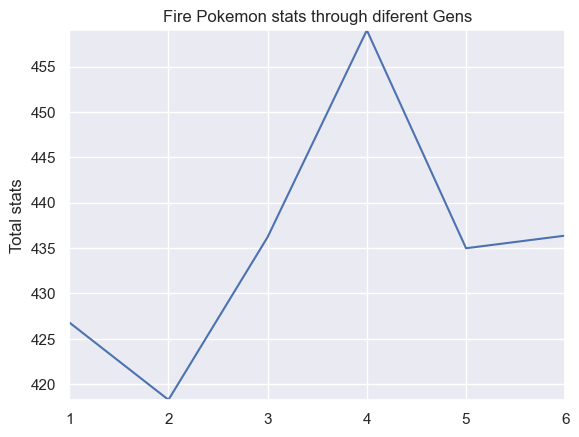

In [17]:
fig, ax = plt.subplots()
plot(x, y1, ax, 'Fire Pokemon stats through diferent Gens', 'Total stats')